In [ ]:
# ============================================================
# Load Cboe VIX and VIX9D histories
# ============================================================

CBOE_URLS = {
    "VIX": "https://cdn.cboe.com/api/global/us_indices/daily_prices/VIX_History.csv",
    "VIX9D": "https://cdn.cboe.com/api/global/us_indices/daily_prices/VIX9D_History.csv",
}


def load_cboe_index_history(symbol, force_refresh=False):
    symbol = symbol.upper()
    url = CBOE_URLS[symbol]
    local_path = EXTERNAL_DATA_DIR / f"cboe_{symbol.lower()}_history.csv"

    if local_path.exists() and not force_refresh:
        df = pd.read_csv(local_path)
    else:
        df = pd.read_csv(url)
        df.to_csv(local_path, index=False)

    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]

    date_col = None
    for candidate in ["DATE", "Date", "date"]:
        if candidate in df.columns:
            date_col = candidate
            break

    close_col = None
    for candidate in ["CLOSE", "Close", "close"]:
        if candidate in df.columns:
            close_col = candidate
            break

    if date_col is None:
        raise ValueError(f"Could not find date column in {symbol}. Columns: {list(df.columns)}")

    if close_col is None:
        raise ValueError(f"Could not find close column in {symbol}. Columns: {list(df.columns)}")

    df["trade_date"] = pd.to_datetime(df[date_col]).dt.strftime("%Y%m%d").astype(int)
    df[f"{symbol.lower()}_close"] = pd.to_numeric(df[close_col], errors="coerce")

    df = (
        df[["trade_date", f"{symbol.lower()}_close"]]
        .dropna()
        .drop_duplicates("trade_date")
        .sort_values("trade_date")
        .reset_index(drop=True)
    )

    print(symbol, "rows:", len(df))
    print(symbol, "min date:", df["trade_date"].min())
    print(symbol, "max date:", df["trade_date"].max())
    print("Saved to:", local_path)

    return df


cboe_vix_df = load_cboe_index_history("VIX", force_refresh=True)
cboe_vix9d_df = load_cboe_index_history("VIX9D", force_refresh=True)

In [5]:
# ============================================================
# Join Cboe VIX / VIX9D to our 30d / 9d tenor rows
# ============================================================

history_df = load_existing_term_structure_history()

METHODOLOGY_VERSION = "v0.7_exchange_calendar_fred_sofr_market_close"

our_30d = (
    history_df[
        (history_df["target_days"] == 30)
        & (history_df["methodology_version"] == METHODOLOGY_VERSION)
    ]
    [["trade_date", "vix_style_vol"]]
    .rename(columns={"vix_style_vol": "our_30d"})
    .copy()
)

our_9d = (
    history_df[
        (history_df["target_days"] == 9)
        & (history_df["methodology_version"] == METHODOLOGY_VERSION)
    ]
    [["trade_date", "vix_style_vol"]]
    .rename(columns={"vix_style_vol": "our_9d"})
    .copy()
)

vix_compare_df = our_30d.merge(cboe_vix_df, on="trade_date", how="inner")
vix_compare_df["diff"] = vix_compare_df["our_30d"] - vix_compare_df["vix_close"]
vix_compare_df["abs_diff"] = vix_compare_df["diff"].abs()

vix9d_compare_df = our_9d.merge(cboe_vix9d_df, on="trade_date", how="inner")
vix9d_compare_df["diff"] = vix9d_compare_df["our_9d"] - vix9d_compare_df["vix9d_close"]
vix9d_compare_df["abs_diff"] = vix9d_compare_df["diff"].abs()

print("Our 30d rows:", len(our_30d))
print("Our 9d rows:", len(our_9d))
print("VIX comparison rows:", len(vix_compare_df))
print("VIX9D comparison rows:", len(vix9d_compare_df))

display(vix_compare_df.head())
display(vix9d_compare_df.head())

Our 30d rows: 2011
Our 9d rows: 2011
VIX comparison rows: 2011
VIX9D comparison rows: 2011


,trade_date,our_30d,vix_close,diff,abs_diff
0,20180625,17.330003,17.33,0.000003,0.000003
1,20180626,16.123595,15.92,0.203595,0.203595
2,20180627,17.775617,17.91,-0.134383,0.134383
3,20180628,16.891110,16.85,0.041110,0.041110
4,20180629,17.231185,16.09,1.141185,1.141185


,trade_date,our_9d,vix9d_close,diff,abs_diff
0,20180625,17.348587,17.68,-0.331413,0.331413
1,20180626,15.359305,15.16,0.199305,0.199305
2,20180627,17.866806,17.91,-0.043194,0.043194
3,20180628,15.956605,15.83,0.126605,0.126605
4,20180629,16.193530,14.93,1.263530,1.263530


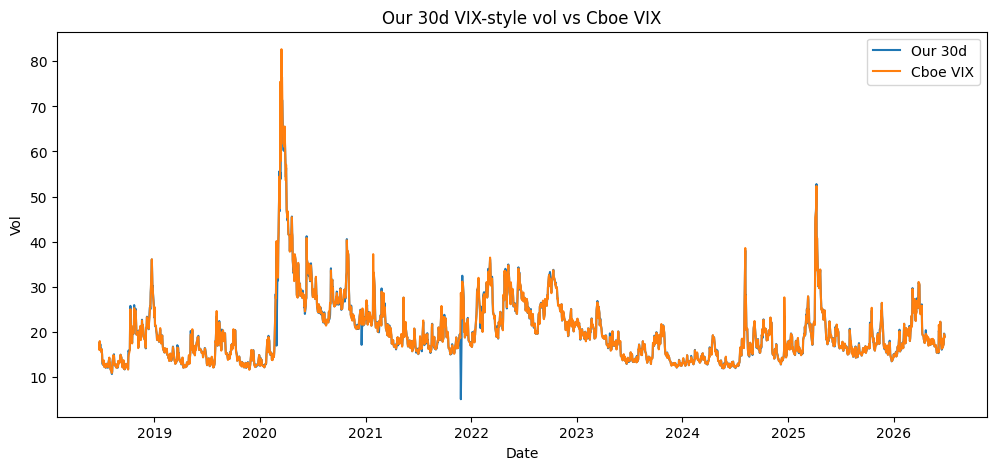

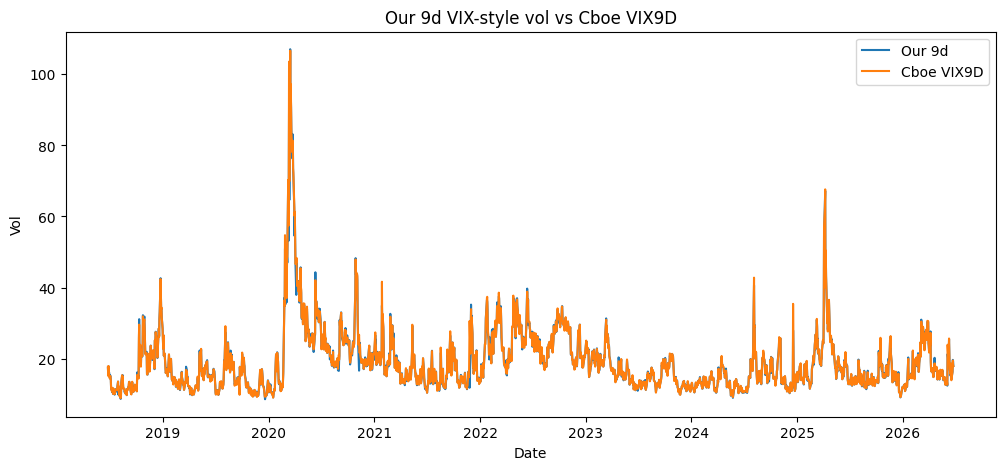

In [6]:
# ============================================================
# Plot comparisons
# ============================================================

import matplotlib.pyplot as plt

vix_plot_df = vix_compare_df.copy()
vix_plot_df["date"] = pd.to_datetime(vix_plot_df["trade_date"].astype(str))

plt.figure(figsize=(12, 5))
plt.plot(vix_plot_df["date"], vix_plot_df["our_30d"], label="Our 30d")
plt.plot(vix_plot_df["date"], vix_plot_df["vix_close"], label="Cboe VIX")
plt.title("Our 30d VIX-style vol vs Cboe VIX")
plt.xlabel("Date")
plt.ylabel("Vol")
plt.legend()
plt.show()

vix9d_plot_df = vix9d_compare_df.copy()
vix9d_plot_df["date"] = pd.to_datetime(vix9d_plot_df["trade_date"].astype(str))

plt.figure(figsize=(12, 5))
plt.plot(vix9d_plot_df["date"], vix9d_plot_df["our_9d"], label="Our 9d")
plt.plot(vix9d_plot_df["date"], vix9d_plot_df["vix9d_close"], label="Cboe VIX9D")
plt.title("Our 9d VIX-style vol vs Cboe VIX9D")
plt.xlabel("Date")
plt.ylabel("Vol")
plt.legend()
plt.show()

In [7]:
# ============================================================
# Inspect worst 30d differences vs Cboe VIX
# ============================================================

display(
    vix_compare_df
    .sort_values("abs_diff", ascending=False)
    .head(25)
)

,trade_date,our_30d,vix_close,diff,abs_diff
863,20211126,5.017273,28.62,-23.602727,23.602727
422,20200228,16.911408,40.11,-23.198592,23.198592
431,20200312,55.327793,75.47,-20.142207,20.142207
1632,20241218,15.996427,27.62,-11.623573,11.623573
434,20200317,69.941425,75.91,-5.968575,5.968575
435,20200318,71.462921,76.45,-4.987079,4.987079
652,20210127,32.372845,37.21,-4.837155,4.837155
627,20201218,17.082908,21.57,-4.487092,4.487092
432,20200313,53.886647,57.83,-3.943353,3.943353
550,20200831,23.661672,26.41,-2.748328,2.748328


In [8]:
# ============================================================
# Detailed 30d VIX comparison with methodology metadata
# ============================================================

history_df = load_existing_term_structure_history()

METHODOLOGY_VERSION = "v0.7_exchange_calendar_fred_sofr_market_close"

metadata_cols = [
    "trade_date",
    "target_days",
    "vix_style_vol",
    "methodology_version",
    "market_close_time",
    "quote_time_used",
    "quote_time_offset_minutes",
    "rate",
    "rate_source",
    "option_source",
]

# Keep only columns that actually exist in your file
metadata_cols = [c for c in metadata_cols if c in history_df.columns]

our_30d_debug = (
    history_df[
        (history_df["target_days"] == 30)
        & (history_df["methodology_version"] == METHODOLOGY_VERSION)
    ][metadata_cols]
    .rename(columns={"vix_style_vol": "our_30d"})
    .copy()
)

vix_debug_df = our_30d_debug.merge(cboe_vix_df, on="trade_date", how="inner")
vix_debug_df["diff"] = vix_debug_df["our_30d"] - vix_debug_df["vix_close"]
vix_debug_df["abs_diff"] = vix_debug_df["diff"].abs()

display(
    vix_debug_df
    .sort_values("abs_diff", ascending=False)
    .head(30)
)

,trade_date,target_days,our_30d,methodology_version,market_close_time,quote_time_used,quote_time_offset_minutes,rate_source,option_source,vix_close,diff,abs_diff
863,20211126,30,5.017273,v0.7_exchange_calendar_fred_sofr_market_close,13:00,13:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,28.62,-23.602727,23.602727
422,20200228,30,16.911408,v0.7_exchange_calendar_fred_sofr_market_close,16:00,16:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,40.11,-23.198592,23.198592
431,20200312,30,55.327793,v0.7_exchange_calendar_fred_sofr_market_close,16:00,16:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,75.47,-20.142207,20.142207
1632,20241218,30,15.996427,v0.7_exchange_calendar_fred_sofr_market_close,16:00,16:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,27.62,-11.623573,11.623573
434,20200317,30,69.941425,v0.7_exchange_calendar_fred_sofr_market_close,16:00,16:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,75.91,-5.968575,5.968575
435,20200318,30,71.462921,v0.7_exchange_calendar_fred_sofr_market_close,16:00,16:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,76.45,-4.987079,4.987079
652,20210127,30,32.372845,v0.7_exchange_calendar_fred_sofr_market_close,16:00,16:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,37.21,-4.837155,4.837155
627,20201218,30,17.082908,v0.7_exchange_calendar_fred_sofr_market_close,16:00,16:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,21.57,-4.487092,4.487092
432,20200313,30,53.886647,v0.7_exchange_calendar_fred_sofr_market_close,16:00,16:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,57.83,-3.943353,3.943353
550,20200831,30,23.661672,v0.7_exchange_calendar_fred_sofr_market_close,16:00,16:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,26.41,-2.748328,2.748328


In [9]:
# ============================================================
# 30d VIX replication error summary
# ============================================================

summary_30d = pd.Series({
    "rows": len(vix_debug_df),
    "mean_diff": vix_debug_df["diff"].mean(),
    "median_diff": vix_debug_df["diff"].median(),
    "mean_abs_diff": vix_debug_df["abs_diff"].mean(),
    "median_abs_diff": vix_debug_df["abs_diff"].median(),
    "p95_abs_diff": vix_debug_df["abs_diff"].quantile(0.95),
    "p99_abs_diff": vix_debug_df["abs_diff"].quantile(0.99),
    "max_abs_diff": vix_debug_df["abs_diff"].max(),
    "correlation": vix_debug_df[["our_30d", "vix_close"]].corr().iloc[0, 1],
})

display(summary_30d)


rows               2011.000000
mean_diff            -0.053792
median_diff           0.000608
mean_abs_diff         0.203299
median_abs_diff       0.089585
p95_abs_diff          0.544126
p99_abs_diff          1.431311
max_abs_diff         23.602727
correlation           0.991361
dtype: float64

In [10]:
# ============================================================
# Flag large 30d replication errors
# ============================================================

large_error_threshold = 2.0

large_30d_errors = (
    vix_debug_df[vix_debug_df["abs_diff"] >= large_error_threshold]
    .sort_values("abs_diff", ascending=False)
    .copy()
)

print("Large 30d errors:", len(large_30d_errors))
display(large_30d_errors)

Large 30d errors: 12


,trade_date,target_days,our_30d,methodology_version,market_close_time,quote_time_used,quote_time_offset_minutes,rate_source,option_source,vix_close,diff,abs_diff
863,20211126,30,5.017273,v0.7_exchange_calendar_fred_sofr_market_close,13:00,13:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,28.62,-23.602727,23.602727
422,20200228,30,16.911408,v0.7_exchange_calendar_fred_sofr_market_close,16:00,16:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,40.11,-23.198592,23.198592
431,20200312,30,55.327793,v0.7_exchange_calendar_fred_sofr_market_close,16:00,16:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,75.47,-20.142207,20.142207
1632,20241218,30,15.996427,v0.7_exchange_calendar_fred_sofr_market_close,16:00,16:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,27.62,-11.623573,11.623573
434,20200317,30,69.941425,v0.7_exchange_calendar_fred_sofr_market_close,16:00,16:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,75.91,-5.968575,5.968575
435,20200318,30,71.462921,v0.7_exchange_calendar_fred_sofr_market_close,16:00,16:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,76.45,-4.987079,4.987079
652,20210127,30,32.372845,v0.7_exchange_calendar_fred_sofr_market_close,16:00,16:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,37.21,-4.837155,4.837155
627,20201218,30,17.082908,v0.7_exchange_calendar_fred_sofr_market_close,16:00,16:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,21.57,-4.487092,4.487092
432,20200313,30,53.886647,v0.7_exchange_calendar_fred_sofr_market_close,16:00,16:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,57.83,-3.943353,3.943353
550,20200831,30,23.661672,v0.7_exchange_calendar_fred_sofr_market_close,16:00,16:00,0.0,FRED_SOFR,THETADATA_SPX_SPXW,26.41,-2.748328,2.748328


In [11]:
# ============================================================
# Inspect full term structure on large 30d error dates
# ============================================================

bad_30d_dates = large_30d_errors["trade_date"].tolist()

term_structure_bad_dates = (
    history_df[
        (history_df["trade_date"].isin(bad_30d_dates))
        & (history_df["methodology_version"] == METHODOLOGY_VERSION)
    ]
    [["trade_date", "target_days", "vix_style_vol", "market_close_time", "quote_time_used", "quote_time_offset_minutes"]]
    .sort_values(["trade_date", "target_days"])
    .copy()
)

term_structure_pivot = term_structure_bad_dates.pivot(
    index="trade_date",
    columns="target_days",
    values="vix_style_vol"
)

display(term_structure_pivot)

target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200228,35.245789,27.838048,26.417592,31.390653,33.572471,25.933826,17.861311,16.911408,19.300661
20200312,91.197225,71.816619,57.114292,53.980695,51.626092,49.140911,46.814982,55.327793,65.184262
20200313,64.634899,62.795760,61.408033,60.026108,59.019212,55.657456,52.895250,53.886647,54.684424
20200316,107.055162,101.849588,96.636522,92.998942,89.289969,86.403820,83.129795,80.414657,79.274362
20200317,88.286222,84.691735,81.261254,78.870516,77.080787,75.062590,72.262318,69.941425,69.928818
20200318,94.261457,87.617043,83.376619,69.383352,50.776302,54.464154,64.699108,71.462921,73.205893
20200619,31.526661,32.237150,32.411576,32.425306,32.435109,32.545330,32.630799,33.002005,33.389772
20200831,16.556985,15.358236,14.145252,13.458689,14.490589,15.218667,19.515865,23.661672,25.953206
20201218,16.810256,17.537429,18.969600,20.254453,21.124413,17.525923,14.106113,17.082908,20.497619


In [12]:
# ============================================================
# Inspect local windows around worst 30d outliers
# ============================================================

focus_dates = [20211126, 20200228, 20200312, 20241218]

all_dates = sorted(history_df["trade_date"].unique())

for focus_date in focus_dates:
    idx = all_dates.index(focus_date)
    window_dates = all_dates[max(0, idx - 3): idx + 4]

    window_df = (
        history_df[
            (history_df["trade_date"].isin(window_dates))
            & (history_df["methodology_version"] == METHODOLOGY_VERSION)
        ]
        .pivot(index="trade_date", columns="target_days", values="vix_style_vol")
        .sort_index()
    )

    print(f"\nWindow around {focus_date}:")
    display(window_df)


Window around 20211126:


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20211122,16.368137,16.997094,17.632695,18.043995,18.564920,18.946217,19.209990,19.410541,19.569947
20211123,15.939659,16.733718,17.343657,17.843541,18.367226,18.738846,18.920679,19.064896,19.112870
20211124,14.797174,15.970240,16.634419,17.299685,17.857551,18.219123,18.440924,18.581821,18.633546
20211126,11.818399,15.722775,18.273006,20.894634,22.173953,14.850471,3.105452,5.017273,6.720199
20211129,21.444919,21.739181,22.039152,22.250218,22.513821,22.709515,22.714302,22.718131,22.776897
20211130,28.963215,28.649490,28.316542,28.143730,28.079669,27.973032,27.785203,27.634021,27.614304
20211201,35.201273,34.174661,33.543616,33.427262,33.429212,33.119360,32.736005,32.426059,32.309036



Window around 20200228:


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200225,37.107379,34.872148,32.927023,31.455005,30.165801,29.195279,28.726344,28.345611,27.926122
20200226,34.826480,32.582294,31.158292,29.830261,28.691679,27.964523,27.578729,27.266163,26.864675
20200227,50.925949,47.386498,45.129779,42.603492,40.703115,39.413458,38.437710,37.517125,36.519643
20200228,35.245789,27.838048,26.417592,31.390653,33.572471,25.933826,17.861311,16.911408,19.300661
20200302,38.222950,36.598353,35.000170,33.897864,33.132153,32.546050,32.040246,31.610368,31.231592
20200303,47.681190,45.217374,43.219980,41.700045,40.416681,39.426753,38.668889,38.051733,37.298802
20200304,35.885516,34.479162,33.607113,32.953995,32.462959,32.054516,31.669831,31.358684,31.070817



Window around 20200312:


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200309,70.094342,66.926010,64.769493,63.291006,60.847567,58.948560,57.177368,55.603709,54.354920
20200310,53.131904,52.069246,51.566281,50.800927,49.497820,48.497517,47.536210,46.752935,45.356500
20200311,67.854411,64.419240,62.267238,59.967959,57.903774,56.312928,55.056431,53.978919,52.986107
20200312,91.197225,71.816619,57.114292,53.980695,51.626092,49.140911,46.814982,55.327793,65.184262
20200313,64.634899,62.795760,61.408033,60.026108,59.019212,55.657456,52.895250,53.886647,54.684424
20200316,107.055162,101.849588,96.636522,92.998942,89.289969,86.403820,83.129795,80.414657,79.274362
20200317,88.286222,84.691735,81.261254,78.870516,77.080787,75.062590,72.262318,69.941425,69.928818



Window around 20241218:


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20241213,10.933019,10.875270,11.125803,11.743264,12.165135,12.871250,13.394741,13.750770,14.013709
20241216,11.786810,11.758205,12.250736,12.568371,13.288291,13.803613,14.205502,14.525173,14.733906
20241217,13.142701,13.272000,13.541201,13.934665,14.566410,15.022795,15.385627,15.669846,15.784133
20241218,27.969565,26.707599,25.920945,25.533146,25.317303,23.723094,19.432563,15.996427,19.950776
20241219,23.051445,23.687647,24.061295,24.101679,24.130482,23.930859,23.674813,23.467307,23.295337
20241220,15.447000,16.468738,17.046032,17.409845,17.665125,17.889513,18.062109,18.187851,18.286848
20241223,14.699352,15.096129,15.689402,16.072757,16.328349,16.517448,16.706262,16.868149,17.040397


In [13]:
# ============================================================
# 30d VIX comparison stats with and without large outliers
# ============================================================

def summarize_vix_error(df, label):
    return pd.Series({
        "label": label,
        "rows": len(df),
        "mean_diff": df["diff"].mean(),
        "median_diff": df["diff"].median(),
        "mean_abs_diff": df["abs_diff"].mean(),
        "median_abs_diff": df["abs_diff"].median(),
        "p95_abs_diff": df["abs_diff"].quantile(0.95),
        "p99_abs_diff": df["abs_diff"].quantile(0.99),
        "max_abs_diff": df["abs_diff"].max(),
        "correlation": df[["our_30d", "vix_close"]].corr().iloc[0, 1],
    })

vix_no_large_errors = vix_debug_df[vix_debug_df["abs_diff"] < 2.0].copy()

vix_error_summary_clean = pd.DataFrame([
    summarize_vix_error(vix_debug_df, "All dates"),
    summarize_vix_error(vix_no_large_errors, "Excluding abs diff >= 2.0"),
])

display(vix_error_summary_clean)

,label,rows,mean_diff,median_diff,mean_abs_diff,median_abs_diff,p95_abs_diff,p99_abs_diff,max_abs_diff,correlation
0,All dates,2011,-0.053792,0.000608,0.203299,0.089585,0.544126,1.431311,23.602727,0.991361
1,Excluding abs diff >= 2.0,1999,0.000878,0.001340,0.149526,0.088834,0.511183,1.035539,1.966939,0.999330


In [14]:
# ============================================================
# VIX9D comparison stats with and without large outliers
# ============================================================

vix9d_debug_df = vix9d_compare_df.copy()

def summarize_error(df, our_col, cboe_col, label):
    return pd.Series({
        "label": label,
        "rows": len(df),
        "mean_diff": df["diff"].mean(),
        "median_diff": df["diff"].median(),
        "mean_abs_diff": df["abs_diff"].mean(),
        "median_abs_diff": df["abs_diff"].median(),
        "p95_abs_diff": df["abs_diff"].quantile(0.95),
        "p99_abs_diff": df["abs_diff"].quantile(0.99),
        "max_abs_diff": df["abs_diff"].max(),
        "correlation": df[[our_col, cboe_col]].corr().iloc[0, 1],
    })

# 9d is naturally jumpier, so start with a wider threshold
vix9d_large_threshold = 3.0

vix9d_no_large_errors = vix9d_debug_df[
    vix9d_debug_df["abs_diff"] < vix9d_large_threshold
].copy()

vix9d_error_summary = pd.DataFrame([
    summarize_error(vix9d_debug_df, "our_9d", "vix9d_close", "VIX9D all dates"),
    summarize_error(vix9d_no_large_errors, "our_9d", "vix9d_close", "VIX9D excluding abs diff >= 3.0"),
])

display(vix9d_error_summary)

large_9d_errors = (
    vix9d_debug_df[vix9d_debug_df["abs_diff"] >= vix9d_large_threshold]
    .sort_values("abs_diff", ascending=False)
    .copy()
)

print("Large 9d errors:", len(large_9d_errors))
display(large_9d_errors.head(30))

,label,rows,mean_diff,median_diff,mean_abs_diff,median_abs_diff,p95_abs_diff,p99_abs_diff,max_abs_diff,correlation
0,VIX9D all dates,2011,-0.069644,-0.005384,0.280686,0.136319,0.793365,2.319823,18.781601,0.995595
1,VIX9D excluding abs diff >= 3.0,1996,-0.015151,-0.004170,0.223412,0.135093,0.715552,1.558872,2.958543,0.999051


Large 9d errors: 15


,trade_date,our_9d,vix9d_close,diff,abs_diff
863,20211126,11.818399,30.60,-18.781601,18.781601
422,20200228,35.245789,52.90,-17.654211,17.654211
431,20200312,91.197225,103.56,-12.362775,12.362775
599,20201109,16.629589,26.71,-10.080411,10.080411
448,20200406,37.946258,47.02,-9.073742,9.073742
1632,20241218,27.969565,35.42,-7.450435,7.450435
652,20210127,34.949383,41.64,-6.690617,6.690617
444,20200331,54.523910,60.16,-5.636090,5.636090
432,20200313,64.634899,69.87,-5.235101,5.235101
434,20200317,88.286222,92.93,-4.643778,4.643778


In [15]:
# ============================================================
# Save benchmark comparison / outlier audit files
# ============================================================

BENCHMARK_DIR = PROJECT_ROOT / "data" / "audit"
BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)

vix_debug_df.to_csv(
    BENCHMARK_DIR / "v0_7_our_30d_vs_cboe_vix.csv",
    index=False
)

vix9d_debug_df.to_csv(
    BENCHMARK_DIR / "v0_7_our_9d_vs_cboe_vix9d.csv",
    index=False
)

large_30d_errors.to_csv(
    BENCHMARK_DIR / "v0_7_large_30d_vix_errors.csv",
    index=False
)

large_9d_errors.to_csv(
    BENCHMARK_DIR / "v0_7_large_9d_vix9d_errors.csv",
    index=False
)

print("Saved audit files to:", BENCHMARK_DIR)

Saved audit files to: C:\Users\patri\vrp_project\data\audit


In [16]:
# ============================================================
# Compare 30d and 9d benchmark outlier dates
# ============================================================

large_30d_dates = set(large_30d_errors["trade_date"])
large_9d_dates = set(large_9d_errors["trade_date"])

overlap_dates = sorted(large_30d_dates & large_9d_dates)
only_30d_dates = sorted(large_30d_dates - large_9d_dates)
only_9d_dates = sorted(large_9d_dates - large_30d_dates)

print("Large 30d errors:", len(large_30d_dates))
print("Large 9d errors:", len(large_9d_dates))
print("Overlap:", len(overlap_dates))
print("Only 30d:", len(only_30d_dates))
print("Only 9d:", len(only_9d_dates))

print("\nOverlap dates:")
print(overlap_dates)

print("\nOnly 30d dates:")
print(only_30d_dates)

print("\nOnly 9d dates:")
print(only_9d_dates)

Large 30d errors: 12
Large 9d errors: 15
Overlap: 8
Only 30d: 4
Only 9d: 7

Overlap dates:
[20200228, 20200312, 20200313, 20200317, 20200831, 20210127, 20211126, 20241218]

Only 30d dates:
[20200316, 20200318, 20200619, 20201218]

Only 9d dates:
[20190923, 20200227, 20200302, 20200310, 20200331, 20200406, 20201109]


In [17]:
# ============================================================
# Full term structure on all benchmark outlier dates
# ============================================================

all_outlier_dates = sorted(large_30d_dates | large_9d_dates)

term_structure_outliers = (
    history_df[
        (history_df["trade_date"].isin(all_outlier_dates))
        & (history_df["methodology_version"] == METHODOLOGY_VERSION)
    ]
    .pivot(index="trade_date", columns="target_days", values="vix_style_vol")
    .sort_index()
)

display(term_structure_outliers)

target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20190923,14.187503,14.383807,14.529551,14.625907,14.725380,14.799546,14.968272,15.133623,15.308728
20200227,50.925949,47.386498,45.129779,42.603492,40.703115,39.413458,38.437710,37.517125,36.519643
20200228,35.245789,27.838048,26.417592,31.390653,33.572471,25.933826,17.861311,16.911408,19.300661
20200302,38.222950,36.598353,35.000170,33.897864,33.132153,32.546050,32.040246,31.610368,31.231592
20200310,53.131904,52.069246,51.566281,50.800927,49.497820,48.497517,47.536210,46.752935,45.356500
20200312,91.197225,71.816619,57.114292,53.980695,51.626092,49.140911,46.814982,55.327793,65.184262
20200313,64.634899,62.795760,61.408033,60.026108,59.019212,55.657456,52.895250,53.886647,54.684424
20200316,107.055162,101.849588,96.636522,92.998942,89.289969,86.403820,83.129795,80.414657,79.274362
20200317,88.286222,84.691735,81.261254,78.870516,77.080787,75.062590,72.262318,69.941425,69.928818


In [18]:
# ============================================================
# Local windows around key outliers
# ============================================================

focus_dates = [20211126, 20200228, 20200312, 20201109, 20241218, 20190923]

all_history_dates = sorted(history_df["trade_date"].unique())

for focus_date in focus_dates:
    if focus_date not in all_history_dates:
        print(f"{focus_date} not found in history")
        continue

    idx = all_history_dates.index(focus_date)
    window_dates = all_history_dates[max(0, idx - 3): idx + 4]

    window_df = (
        history_df[
            (history_df["trade_date"].isin(window_dates))
            & (history_df["methodology_version"] == METHODOLOGY_VERSION)
        ]
        .pivot(index="trade_date", columns="target_days", values="vix_style_vol")
        .sort_index()
    )

    print(f"\nWindow around {focus_date}:")
    display(window_df)


Window around 20211126:


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20211122,16.368137,16.997094,17.632695,18.043995,18.564920,18.946217,19.209990,19.410541,19.569947
20211123,15.939659,16.733718,17.343657,17.843541,18.367226,18.738846,18.920679,19.064896,19.112870
20211124,14.797174,15.970240,16.634419,17.299685,17.857551,18.219123,18.440924,18.581821,18.633546
20211126,11.818399,15.722775,18.273006,20.894634,22.173953,14.850471,3.105452,5.017273,6.720199
20211129,21.444919,21.739181,22.039152,22.250218,22.513821,22.709515,22.714302,22.718131,22.776897
20211130,28.963215,28.649490,28.316542,28.143730,28.079669,27.973032,27.785203,27.634021,27.614304
20211201,35.201273,34.174661,33.543616,33.427262,33.429212,33.119360,32.736005,32.426059,32.309036



Window around 20200228:


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200225,37.107379,34.872148,32.927023,31.455005,30.165801,29.195279,28.726344,28.345611,27.926122
20200226,34.826480,32.582294,31.158292,29.830261,28.691679,27.964523,27.578729,27.266163,26.864675
20200227,50.925949,47.386498,45.129779,42.603492,40.703115,39.413458,38.437710,37.517125,36.519643
20200228,35.245789,27.838048,26.417592,31.390653,33.572471,25.933826,17.861311,16.911408,19.300661
20200302,38.222950,36.598353,35.000170,33.897864,33.132153,32.546050,32.040246,31.610368,31.231592
20200303,47.681190,45.217374,43.219980,41.700045,40.416681,39.426753,38.668889,38.051733,37.298802
20200304,35.885516,34.479162,33.607113,32.953995,32.462959,32.054516,31.669831,31.358684,31.070817



Window around 20200312:


...

target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20201104,32.541149,31.453124,30.781855,30.229350,29.801400,29.615310,29.716391,29.797008,29.810150
20201105,28.710291,28.315216,28.059595,27.753108,27.532100,27.650069,27.866746,28.004557,28.054539
20201106,23.921310,24.069676,24.100496,24.055415,24.023162,24.347576,24.596940,24.833145,25.042101
20201109,16.629589,17.692494,22.331622,24.949669,25.194168,25.375997,25.533486,25.666373,24.681885
20201110,24.501214,24.182846,23.970065,24.007001,24.338228,24.583721,24.747992,24.878629,24.953487
20201111,21.885266,21.806840,21.759648,22.226040,22.760260,23.155071,23.461469,23.703736,23.805581
20201112,24.434144,24.191230,24.044304,24.665222,25.099332,25.410940,25.646674,25.787759,25.819231



Window around 20241218:


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20241213,10.933019,10.875270,11.125803,11.743264,12.165135,12.871250,13.394741,13.750770,14.013709
20241216,11.786810,11.758205,12.250736,12.568371,13.288291,13.803613,14.205502,14.525173,14.733906
20241217,13.142701,13.272000,13.541201,13.934665,14.566410,15.022795,15.385627,15.669846,15.784133
20241218,27.969565,26.707599,25.920945,25.533146,25.317303,23.723094,19.432563,15.996427,19.950776
20241219,23.051445,23.687647,24.061295,24.101679,24.130482,23.930859,23.674813,23.467307,23.295337
20241220,15.447000,16.468738,17.046032,17.409845,17.665125,17.889513,18.062109,18.187851,18.286848
20241223,14.699352,15.096129,15.689402,16.072757,16.328349,16.517448,16.706262,16.868149,17.040397



Window around 20190923:


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20190918,14.209713,14.033648,13.926940,13.947592,14.001631,14.079374,14.205419,14.314141,14.481319
20190919,13.656743,13.746679,13.800359,13.885627,13.946214,13.952645,13.940355,14.057651,14.307548
20190920,14.802680,14.961750,15.067808,15.157029,15.220438,15.292748,15.348754,15.455212,15.559666
20190923,14.187503,14.383807,14.529551,14.625907,14.725380,14.799546,14.968272,15.133623,15.308728
20190924,17.649887,17.516096,17.464742,17.143299,16.399056,15.927830,16.525859,16.989132,17.290355
20190925,15.231608,15.364920,15.444355,15.451991,15.438083,15.537221,15.744760,15.908842,16.193503
20190926,15.189638,15.350174,15.445694,15.478175,15.501333,15.689076,15.881416,16.083875,16.337693


In [21]:
# ============================================================
# Inspect available columns in saved v0.7 history
# ============================================================

history_df = load_existing_term_structure_history()

print("Columns in history_df:")
for c in history_df.columns:
    print(c)

Columns in history_df:
trade_date
target_days
rate_symbol
rate_pct
implied_variance
vix_style_vol
near_root
near_expiration
near_days
near_variance
next_root
next_expiration
next_days
next_variance
methodology_version
expiration_universe
trading_calendar_source
rate_source
option_source
quote_time
calc_time_ms
market_close_time
quote_time_used
quote_time_offset_minutes


In [22]:
# ============================================================
# Inspect suspect dates using whatever metadata is saved
# ============================================================

suspect_dates = [
    20211126,
    20200228,
    20200312,
    20241218,
    20201109,
    20190923,
]

metadata_keywords = [
    "date",
    "target",
    "vol",
    "variance",
    "expiry",
    "expir",
    "root",
    "near",
    "far",
    "minute",
    "time",
    "quote",
    "rate",
    "source",
    "methodology",
]

debug_cols = [
    c for c in history_df.columns
    if any(k in c.lower() for k in metadata_keywords)
]

suspect_history_debug = (
    history_df[
        (history_df["trade_date"].isin(suspect_dates))
        & (history_df["methodology_version"] == METHODOLOGY_VERSION)
    ][debug_cols]
    .sort_values(["trade_date", "target_days"])
    .copy()
)

display(suspect_history_debug)

,trade_date,target_days,rate_symbol,rate_pct,implied_variance,vix_style_vol,near_root,near_expiration,near_days,near_variance,...,methodology_version,expiration_universe,trading_calendar_source,rate_source,option_source,quote_time,calc_time_ms,market_close_time,quote_time_used,quote_time_offset_minutes
2817,20190923,9,SOFR,1.85,0.020129,14.187503,SPXW,20190927,4.000000,0.017589,...,v0.7_exchange_calendar_fred_sofr_market_close,friday_cycle_holiday_adjusted,exchange_calendar_XNYS,FRED_SOFR,THETADATA_SPX_SPXW,market_close,57600000,16:00,16:00,0.0
2818,20190923,12,SOFR,1.85,0.020689,14.383807,SPXW,20191004,11.000000,0.020498,...,v0.7_exchange_calendar_fred_sofr_market_close,friday_cycle_holiday_adjusted,exchange_calendar_XNYS,FRED_SOFR,THETADATA_SPX_SPXW,market_close,57600000,16:00,16:00,0.0
2819,20190923,15,SOFR,1.85,0.021111,14.529551,SPXW,20191004,11.000000,0.020498,...,v0.7_exchange_calendar_fred_sofr_market_close,friday_cycle_holiday_adjusted,exchange_calendar_XNYS,FRED_SOFR,THETADATA_SPX_SPXW,market_close,57600000,16:00,16:00,0.0
2820,20190923,18,SOFR,1.85,0.021392,14.625907,SPXW,20191011,18.000000,0.021392,...,v0.7_exchange_calendar_fred_sofr_market_close,friday_cycle_holiday_adjusted,exchange_calendar_XNYS,FRED_SOFR,THETADATA_SPX_SPXW,market_close,57600000,16:00,16:00,0.0
2821,20190923,21,SOFR,1.85,0.021684,14.725380,SPXW,20191011,18.000000,0.021392,...,v0.7_exchange_calendar_fred_sofr_market_close,friday_cycle_holiday_adjusted,exchange_calendar_XNYS,FRED_SOFR,THETADATA_SPX_SPXW,market_close,57600000,16:00,16:00,0.0
2822,20190923,24,SOFR,1.85,0.021903,14.799546,SPXW,20191011,18.000000,0.021392,...,v0.7_exchange_calendar_fred_sofr_market_close,friday_cycle_holiday_adjusted,exchange_calendar_XNYS,FRED_SOFR,THETADATA_SPX_SPXW,market_close,57600000,16:00,16:00,0.0
2823,20190923,27,SOFR,1.85,0.022405,14.968272,SPX,20191018,24.729167,0.021948,...,v0.7_exchange_calendar_fred_sofr_market_close,friday_cycle_holiday_adjusted,exchange_calendar_XNYS,FRED_SOFR,THETADATA_SPX_SPXW,market_close,57600000,16:00,16:00,0.0
2824,20190923,30,SOFR,1.85,0.022903,15.133623,SPX,20191018,24.729167,0.021948,...,v0.7_exchange_calendar_fred_sofr_market_close,friday_cycle_holiday_adjusted,exchange_calendar_XNYS,FRED_SOFR,THETADATA_SPX_SPXW,market_close,57600000,16:00,16:00,0.0
2825,20190923,33,SOFR,1.85,0.023436,15.308728,SPXW,20191025,32.000000,0.023183,...,v0.7_exchange_calendar_fred_sofr_market_close,friday_cycle_holiday_adjusted,exchange_calendar_XNYS,FRED_SOFR,THETADATA_SPX_SPXW,market_close,57600000,16:00,16:00,0.0
3798,20200228,9,SOFR,1.60,0.124227,35.245789,SPXW,20200306,7.000000,0.177633,...,v0.7_exchange_calendar_fred_sofr_market_close,friday_cycle_holiday_adjusted,exchange_calendar_XNYS,FRED_SOFR,THETADATA_SPX_SPXW,market_close,57600000,16:00,16:00,0.0


In [23]:
# ============================================================
# Create v0.7.1 repaired history file
# Repairs selected bad dates using neighboring curves + Cboe anchors
# ============================================================

history_df = load_existing_term_structure_history().copy()

METHODOLOGY_VERSION = "v0.7_exchange_calendar_fred_sofr_market_close"
REPAIRED_METHODOLOGY_VERSION = "v0.7.1_repaired_neighbor_curve_cboe_anchors"

TARGET_TENOR_DAYS = [9, 12, 15, 18, 21, 24, 27, 30, 33]

# Start conservative: only clearly broken curve-shape dates
REPAIR_DATES = [
    20211126,
    20200228,
    20241218,
]

# Build benchmark anchor table
cboe_anchor_df = (
    cboe_vix9d_df[["trade_date", "vix9d_close"]]
    .merge(cboe_vix_df[["trade_date", "vix_close"]], on="trade_date", how="outer")
)

# Work only with current v0.7 rows
base_df = history_df[
    history_df["methodology_version"] == METHODOLOGY_VERSION
].copy()

# Preserve raw values
base_df["raw_implied_variance"] = base_df["implied_variance"]
base_df["raw_vix_style_vol"] = base_df["vix_style_vol"]
base_df["is_repaired"] = False
base_df["repair_method"] = ""

# Wide matrix of raw curves
curve_var_df = (
    base_df
    .pivot(index="trade_date", columns="target_days", values="implied_variance")
    .sort_index()
)

all_dates = list(curve_var_df.index)

def get_neighbor_dates_for_repair(trade_date, repair_dates):
    """
    Find previous and next non-repair dates around trade_date.
    """
    idx = all_dates.index(trade_date)

    prev_date = None
    for j in range(idx - 1, -1, -1):
        candidate = all_dates[j]
        if candidate not in repair_dates:
            prev_date = candidate
            break

    next_date = None
    for j in range(idx + 1, len(all_dates)):
        candidate = all_dates[j]
        if candidate not in repair_dates:
            next_date = candidate
            break

    if prev_date is None or next_date is None:
        raise ValueError(f"Could not find neighbors for {trade_date}")

    return prev_date, next_date


def date_int_to_timestamp(date_int):
    return pd.to_datetime(str(int(date_int)), format="%Y%m%d")


def make_repaired_curve(trade_date, repair_dates):
    """
    Estimate repaired tenor curve in variance space.
    Uses neighboring curves, then anchors 9d and 30d to Cboe if available.
    """
    prev_date, next_date = get_neighbor_dates_for_repair(trade_date, repair_dates)

    prev_ts = date_int_to_timestamp(prev_date)
    trade_ts = date_int_to_timestamp(trade_date)
    next_ts = date_int_to_timestamp(next_date)

    # Calendar-day interpolation weight
    w = (trade_ts - prev_ts).days / (next_ts - prev_ts).days

    prev_curve = curve_var_df.loc[prev_date, TARGET_TENOR_DAYS].astype(float)
    next_curve = curve_var_df.loc[next_date, TARGET_TENOR_DAYS].astype(float)

    base_curve = (1 - w) * prev_curve + w * next_curve

    anchor_row = cboe_anchor_df[cboe_anchor_df["trade_date"] == trade_date]

    repaired_curve = base_curve.copy()

    # Anchor 9d and 30d to official Cboe benchmarks if available
    if len(anchor_row) == 1:
        anchor_row = anchor_row.iloc[0]

        has_9d_anchor = pd.notna(anchor_row.get("vix9d_close"))
        has_30d_anchor = pd.notna(anchor_row.get("vix_close"))

        if has_9d_anchor and has_30d_anchor:
            target_9_var = (float(anchor_row["vix9d_close"]) / 100) ** 2
            target_30_var = (float(anchor_row["vix_close"]) / 100) ** 2

            base_9_var = float(base_curve.loc[9])
            base_30_var = float(base_curve.loc[30])

            # Linear adjustment in variance by tenor:
            # adjusted_var = base_var + a + b * tenor
            b = ((target_30_var - base_30_var) - (target_9_var - base_9_var)) / (30 - 9)
            a = (target_9_var - base_9_var) - b * 9

            tenors = np.array(TARGET_TENOR_DAYS, dtype=float)
            repaired_values = base_curve.values + a + b * tenors

            # Safety floor to avoid impossible negative variance
            repaired_values = np.maximum(repaired_values, 0.000001)

            repaired_curve = pd.Series(
                repaired_values,
                index=TARGET_TENOR_DAYS
            )

        elif has_30d_anchor:
            target_30_var = (float(anchor_row["vix_close"]) / 100) ** 2
            shift = target_30_var - float(base_curve.loc[30])
            repaired_curve = np.maximum(base_curve + shift, 0.000001)

        elif has_9d_anchor:
            target_9_var = (float(anchor_row["vix9d_close"]) / 100) ** 2
            shift = target_9_var - float(base_curve.loc[9])
            repaired_curve = np.maximum(base_curve + shift, 0.000001)

    return prev_date, next_date, repaired_curve


repair_log_rows = []

repaired_df = base_df.copy()

for trade_date in REPAIR_DATES:
    prev_date, next_date, repaired_curve = make_repaired_curve(
        trade_date=trade_date,
        repair_dates=REPAIR_DATES,
    )

    for tenor in TARGET_TENOR_DAYS:
        mask = (
            (repaired_df["trade_date"] == trade_date)
            & (repaired_df["target_days"] == tenor)
        )

        if mask.sum() != 1:
            raise ValueError(f"Expected one row for {trade_date}, {tenor}; found {mask.sum()}")

        old_var = float(repaired_df.loc[mask, "implied_variance"].iloc[0])
        old_vol = float(repaired_df.loc[mask, "vix_style_vol"].iloc[0])

        new_var = float(repaired_curve.loc[tenor])
        new_vol = np.sqrt(new_var) * 100

        repaired_df.loc[mask, "implied_variance"] = new_var
        repaired_df.loc[mask, "vix_style_vol"] = new_vol
        repaired_df.loc[mask, "is_repaired"] = True
        repaired_df.loc[mask, "repair_method"] = "neighbor_curve_variance_interp_cboe_9d_30d_anchor"
        repaired_df.loc[mask, "methodology_version"] = REPAIRED_METHODOLOGY_VERSION

        repair_log_rows.append({
            "trade_date": trade_date,
            "target_days": tenor,
            "prev_neighbor_date": prev_date,
            "next_neighbor_date": next_date,
            "old_implied_variance": old_var,
            "new_implied_variance": new_var,
            "old_vix_style_vol": old_vol,
            "new_vix_style_vol": new_vol,
            "vol_change": new_vol - old_vol,
        })

repair_log_df = pd.DataFrame(repair_log_rows)

display(repair_log_df)

,trade_date,target_days,prev_neighbor_date,next_neighbor_date,old_implied_variance,new_implied_variance,old_vix_style_vol,new_vix_style_vol,vol_change
0,20211126,9,20211124,20211129,0.013967,0.093636,11.818399,30.600000,18.781601
1,20211126,12,20211124,20211129,0.024721,0.093231,15.722775,30.533691,14.810917
2,20211126,15,20211124,20211129,0.033390,0.091976,18.273006,30.327553,12.054547
3,20211126,18,20211124,20211129,0.043659,0.090625,20.894634,30.104033,9.209399
4,20211126,21,20211124,20211129,0.049168,0.089195,22.173953,29.865509,7.691555
5,20211126,24,20211124,20211129,0.022054,0.087252,14.850471,29.538504,14.688032
6,20211126,27,20211124,20211129,0.000964,0.084670,3.105452,29.098058,25.992605
7,20211126,30,20211124,20211129,0.002517,0.081910,5.017273,28.620000,23.602727
8,20211126,33,20211124,20211129,0.004516,0.079054,6.720199,28.116487,21.396288
9,20200228,9,20200227,20200302,0.124227,0.279841,35.245789,52.900000,17.654211


In [24]:
# ============================================================
# Inspect repaired curves versus raw curves
# ============================================================

raw_curves = (
    base_df[base_df["trade_date"].isin(REPAIR_DATES)]
    .pivot(index="trade_date", columns="target_days", values="raw_vix_style_vol")
    .sort_index()
)

new_curves = (
    repaired_df[repaired_df["trade_date"].isin(REPAIR_DATES)]
    .pivot(index="trade_date", columns="target_days", values="vix_style_vol")
    .sort_index()
)

print("Raw curves:")
display(raw_curves)

print("Repaired curves:")
display(new_curves)

Raw curves:


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200228,35.245789,27.838048,26.417592,31.390653,33.572471,25.933826,17.861311,16.911408,19.300661
20211126,11.818399,15.722775,18.273006,20.894634,22.173953,14.850471,3.105452,5.017273,6.720199
20241218,27.969565,26.707599,25.920945,25.533146,25.317303,23.723094,19.432563,15.996427,19.950776


Repaired curves:


target_days,9,12,15,18,21,24,27,30,33
trade_date,,,,,,,,,
20200228,52.90,49.806169,47.634780,45.359322,43.583408,42.261210,41.164094,40.11,39.001099
20211126,30.60,30.533691,30.327553,30.104033,29.865509,29.538504,29.098058,28.62,28.116487
20241218,35.42,34.559000,33.615872,32.551151,31.503133,30.291501,28.985679,27.62,26.149829


In [25]:
# ============================================================
# Save v0.7.1 repaired history
# ============================================================

REPAIRED_CSV = PROCESSED_DATA_DIR / "vix_term_structure_history_v0_7_1_repaired.csv"
REPAIRED_PARQUET = PROCESSED_DATA_DIR / "vix_term_structure_history_v0_7_1_repaired.parquet"

repaired_df.to_csv(REPAIRED_CSV, index=False)
repaired_df.to_parquet(REPAIRED_PARQUET, index=False)

AUDIT_DIR = PROJECT_ROOT / "data" / "audit"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

repair_log_path = AUDIT_DIR / "v0_7_1_repair_log.csv"
repair_log_df.to_csv(repair_log_path, index=False)

print("Saved repaired CSV:", REPAIRED_CSV)
print("Saved repaired parquet:", REPAIRED_PARQUET)
print("Saved repair log:", repair_log_path)

print("Rows:", len(repaired_df))
print("Repaired rows:", repaired_df["is_repaired"].sum())
print("Repaired dates:", sorted(repaired_df.loc[repaired_df["is_repaired"], "trade_date"].unique()))

Saved repaired CSV: C:\Users\patri\vrp_project\data\processed\vix_term_structure_history_v0_7_1_repaired.csv
Saved repaired parquet: C:\Users\patri\vrp_project\data\processed\vix_term_structure_history_v0_7_1_repaired.parquet
Saved repair log: C:\Users\patri\vrp_project\data\audit\v0_7_1_repair_log.csv
Rows: 18099
Repaired rows: 27
Repaired dates: [np.int64(20200228), np.int64(20211126), np.int64(20241218)]
